In [1]:
import os
os.chdir('../')
%pwd

'd:\\Deep_Learning_Object_Detection\\MLOPs\\pneumonia-segmentation'

In [2]:
from dataclasses import dataclass
from typing import Optional
from pathlib import Path

@dataclass(frozen=True)
class DataDriftMetricsConfig:
    drift_threshold:    float
    n_bins:             int
    max_samples:        Optional[int]
    seed:               int
    model_name:         str

@dataclass(frozen=True)
class DataDriftConfig:
    root_dir: Path
    origin_data_source: Path
    baseline_dir: Path
    metric: DataDriftMetricsConfig

In [3]:
from pneumonia_segmentation.constants import *
from pneumonia_segmentation.utils.common import read_yaml, create_directories

class ConfigurationManger:
    def __init__(self, 
                 config_filepath = CONFIG_FILE_PATH,
                 params_filepath = PARAMS_FILE_PATH):
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)

        create_directories([self.config.artifacts_root])
    
    def get_data_drift_config(self) -> DataDriftConfig:
        config = self.config.data_drift_config
        params = self.params.data_drift_params
        create_directories([config.root_dir])
        
        return DataDriftConfig(
            root_dir=Path(config.root_dir),
            origin_data_source = Path(self.config.data_transformation_config.out_train_dir) / "img",
            baseline_dir = Path(config.root_dir) / "baseline_distribution.npy",
            metric = DataDriftMetricsConfig(
                drift_threshold = params.drift_threshold,
                n_bins = params.n_bins,
                max_samples = params.max_samples,
                seed = params.seed,
                model_name = "resnet50.onnx",
            )
        )

In [ ]:
import sys, numpy as np
from numpy.linalg import norm

from pneumonia_segmentation import logging
from pneumonia_segmentation.exception import CustomException

from pneumonia_segmentation.utils.data_drift_helpers import FeatureExtractor

class DataDriftDetector:
    def __init__(self, config: DataDriftConfig):
        self.config = config
        self.extractor = FeatureExtractor(
            model_name=self.config.metric.model_name, 
            device="cpu"
        )
    
    def _get_distribution(self, img_paths: list[Path]) -> np.ndarray:
        all_features = []
        logging.info(f"Extracting features from {len(img_paths)} images...")
        
        for path in img_paths:
            feat = self.extractor.extract(path)
            all_features.append(feat)
        
        all_features = np.array(all_features)
        avg_feature_vector = np.mean(all_features, axis=0)
        return avg_feature_vector
    
    def run(self) -> dict:
        img_paths = sorted(list(self.config.origin_data_source.rglob("*.png")))
        if self.config.metric.max_samples and len(img_paths) > self.config.metric.max_samples:
            rng = np.random.default_rng(self.config.metric.seed)
            indices = rng.choice(len(img_paths), self.config.metric.max_samples, replace=False)
            img_paths = [img_paths[i] for i in sorted(indices)]
            
        current_avg_feat = self._get_distribution(img_paths)
        if not self.config.baseline_dir.exists():
            np.save(self.config.baseline_dir, current_avg_feat)
            return {"status": "Baseline Created"}

        baseline_avg_feat = np.load(self.config.baseline_dir)
        score = norm(baseline_avg_feat - current_avg_feat)
        
        return {
            "drift_score": float(score),
            "is_drift": score > self.config.metric.drift_threshold
        }

In [5]:
try:
    config = ConfigurationManger()
    data_drift_config = config.get_data_drift_config()
    data_drift = DataDriftDetector(config=data_drift_config)
    data_drift.run()
except Exception as e:
    raise CustomException(e, sys)

[2026-04-17 17:17:57,648: INFO: common: yaml file: config\config.yaml loaded successfully]
[2026-04-17 17:17:57,654: INFO: common: yaml file: params.yaml loaded successfully]
[2026-04-17 17:17:57,656: INFO: common: created directory at: artifacts]
[2026-04-17 17:17:57,657: INFO: common: created directory at: artifacts/data_drift]
[2026-04-17 17:17:58,221: INFO: 2830862090: Extracting features from 2423 images...]


# TEST

[LUNG PHOTO (TRAIN)]
Path: artifacts\data_transformation\train\img\scan_00003.png
Drift Score: 40.312046
Is Drift: False
------------------------------
[LUNG PHOTO (INFER)]
Path: D:\Deep_Learning_Object_Detection\MLOPs\pneumonia-segmentation\artifacts\data_transformation\infer\img\scan_00128.png
Drift Score: 38.571037
Is Drift: False
------------------------------
[GARBAGE PHOTO (OOD)]
Path: C:\Users\MINH KHAI\Pictures\Screenshots\Screenshot 2025-09-08 200749.png
Drift Score: 97.996384
Is Drift: True
------------------------------


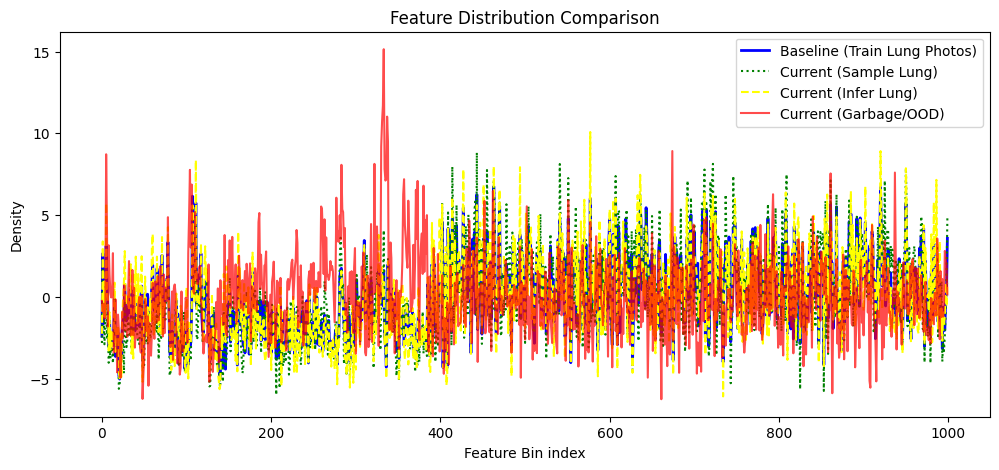

In [8]:
import matplotlib.pyplot as plt
baseline_dist = np.load(data_drift_config.baseline_dir)

def test_drift(img_path, label):
    feat = data_drift.extractor.extract(Path(img_path))
    score = norm(baseline_dist - feat)
    is_drift = score > data_drift_config.metric.drift_threshold
    
    print(f"[{label}]")
    print(f"Path: {img_path}")
    print(f"Drift Score: {score:.6f}")
    print(f"Is Drift: {is_drift}")
    print("-" * 30)
    return feat, score

# Test 1: Train data
train_sample = sorted(list(data_drift_config.origin_data_source.rglob("*.png")))[2]
dist1, score1 = test_drift(train_sample, "LUNG PHOTO (TRAIN)")

# Test 2: Infer data
infer_sample = r"D:\Deep_Learning_Object_Detection\MLOPs\pneumonia-segmentation\artifacts\data_transformation\infer\img\scan_00128.png"
dist2, score2 = test_drift(infer_sample, "LUNG PHOTO (INFER)")

# Test 3: garbage data
garbage_sample = r"C:\Users\MINH KHAI\Pictures\Screenshots\Screenshot 2025-09-08 200749.png"
dist3, score3 = test_drift(garbage_sample, "GARBAGE PHOTO (OOD)")

plt.figure(figsize=(12, 5))
plt.plot(baseline_dist, label="Baseline (Train Lung Photos)", color='blue', linewidth=2)
plt.plot(dist1, label="Current (Sample Lung)", color='green', linestyle=':')
plt.plot(dist2, label="Current (Infer Lung)", color='yellow', linestyle='--')
plt.plot(dist3, label="Current (Garbage/OOD)", color='red', alpha=0.7)
plt.title("Feature Distribution Comparison")
plt.xlabel("Feature Bin index")
plt.ylabel("Density")
plt.legend()
plt.show()